In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("Ev sales_dataset.csv")
print(df)

      YEAR       2 W      3 W     4 W  BUS     TOTAL
0   Apr-17      96.0   4748.0   198.0    0    5042.0
1   May-17      91.0   6720.0   215.0    2    7028.0
2   Jun-17     137.0   7178.0   149.0    1    7465.0
3   Jul-17     116.0   8775.0   120.0    0    9011.0
4   Aug-17      99.0   8905.0   137.0    0    9141.0
..     ...       ...      ...     ...  ...       ...
70  Feb-23   66033.0  35995.0  4850.0   99  106977.0
71  Mar-23   86194.0  45225.0  8852.0   89  140360.0
72  Apr-23   66755.0  38016.0  6193.0   84  111048.0
73  May-23  105154.0  44615.0  7736.0  283  157788.0
74     NaN       NaN      NaN     NaN  NaN       NaN

[75 rows x 6 columns]


In [4]:
# 1. Inspect the Data
print("\n--- Initial Data Inspection ---")
print(df.head(10))  # Show the first few rows


--- Initial Data Inspection ---
     YEAR    2 W     3 W    4 W BUS    TOTAL
0  Apr-17   96.0  4748.0  198.0   0   5042.0
1  May-17   91.0  6720.0  215.0   2   7028.0
2  Jun-17  137.0  7178.0  149.0   1   7465.0
3  Jul-17  116.0  8775.0  120.0   0   9011.0
4  Aug-17   99.0  8905.0  137.0   0   9141.0
5  Sep-17  109.0  7414.0  193.0   0   7716.0
6  Oct-17  160.0  7250.0  214.0   s   7624.0
7  Nov-17  214.0  9598.0  186.0  11  10009.0
8  Dec-17  189.0  8719.0  179.0   0   9087.0
9  Jan-18  176.0  8750.0  210.0  29   9165.0


In [5]:
# 2. Handle Missing Values
print("\n--- Missing Values ---")
print("Missing values before:\n", df.isnull().sum())
df.fillna(0, inplace=True)  # Fill missing with 0
print("\nMissing values after:\n", df.isnull().sum())


--- Missing Values ---
Missing values before:
 YEAR     1
2 W      1
3 W      1
4 W      1
BUS      1
TOTAL    1
dtype: int64

Missing values after:
 YEAR     0
2 W      0
3 W      0
4 W      0
BUS      0
TOTAL    0
dtype: int64


In [6]:
# 3. Handle Duplicates
print("\n--- Duplicates ---")
print("Duplicates before:", df.duplicated().sum())  # Count duplicates
df.drop_duplicates(inplace=True)  # Remove duplicates
print("Duplicates after:", df.duplicated().sum())


--- Duplicates ---
Duplicates before: 0
Duplicates after: 0


In [21]:
# 4. Rename Columns
print("\n--- Column Renaming ---")
print("Columns before:\n", df.columns)

df = df.rename(columns={
    '2 W': 'Two_Wheelers', 
    '3 W': 'Three_Wheelers',  
    '4 W': 'Four_Wheelers',  
    'Bus': 'Bus',       
    'Total':'Total'
})

print("Columns after:\n", df.columns)


--- Column Renaming ---
Columns before:
 Index(['YEAR', '2 W', '3 W', '4 W', 'BUS', 'Total'], dtype='object')
Columns after:
 Index(['YEAR', 'Two_Wheelers', 'Three_Wheelers', 'Four_Wheelers', 'BUS',
       'Total'],
      dtype='object')


In [22]:
# 5.Total EV Sales Over Time
total_sales_over_time = df['Total']
print("Total EV Sales Over Time:")
print(total_sales_over_time.head(10))

Total EV Sales Over Time:
0     5042.0
1     7028.0
2     7465.0
3     9011.0
4     9141.0
5     7716.0
6     7624.0
7    10009.0
8     9087.0
9     9165.0
Name: Total, dtype: float64


In [23]:
# 6. Average Monthly Sales: 
average_monthly_sales = df['Total'].mean()
print(f"\nAverage Monthly Sales: {average_monthly_sales:.2f}")


Average Monthly Sales: 32703.03


In [25]:
# 7. Monthly Sales by Vehicle Type: Displaying the sales figures for each vehicle type (2W, 3W, 4W, BUS,) for the first few months.
sales_by_type = df[['Two_Wheelers','Three_Wheelers','Four_Wheelers','BUS']]
print("\n firstfew months sales by Vehicle Type:")
print(sales_by_type.head(10))


 firstfew months sales by Vehicle Type:
   Two_Wheelers  Three_Wheelers  Four_Wheelers BUS
0          96.0          4748.0          198.0   0
1          91.0          6720.0          215.0   2
2         137.0          7178.0          149.0   1
3         116.0          8775.0          120.0   0
4          99.0          8905.0          137.0   0
5         109.0          7414.0          193.0   0
6         160.0          7250.0          214.0   s
7         214.0          9598.0          186.0  11
8         189.0          8719.0          179.0   0
9         176.0          8750.0          210.0  29


In [34]:
# 8. Percentage Contribution of Each Vehicle Type to Total Sales (Overall):
overall_contribution = (df[['Two_Wheelers','Three_Wheelers','Four_Wheelers']].sum() / df['Total'].sum()) * 100
print("\nOverall Percentage Contribution of Each Vehicle Type:")
print(overall_contribution)


Overall Percentage Contribution of Each Vehicle Type:
Two_Wheelers      51.104995
Three_Wheelers    44.807270
Four_Wheelers      3.839400
dtype: float64


In [35]:
# 9. Monthly Growth Rate of Total Sales: Calculating the percentage change in total sales from the previous month.
monthly_growth_rate = df['Total'].pct_change() * 100
print("\nMonthly Growth Rate of Total Sales:")
print(monthly_growth_rate.head(10))


Monthly Growth Rate of Total Sales:
0          NaN
1    39.389131
2     6.217985
3    20.709980
4     1.442681
5   -15.589104
6    -1.192328
7    31.282791
8    -9.211709
9     0.858369
Name: Total, dtype: float64


In [36]:
# 10. Comparison of Sales Between Two Vehicle Types 
comparison_2W_4W = df[['Two_Wheelers', 'Four_Wheelers']].sum()
print("\nComparison of Two_Wheelers vs Four_Wheelers Total Sales:")
print(comparison_2W_4W)


Comparison of Two_Wheelers vs Four_Wheelers Total Sales:
Two_Wheelers     1253466.0
Four_Wheelers      94170.0
dtype: float64


In [37]:
# 11.Finding the Month with the Highest Total Sales
max_row = df[df['Total'] == df['Total'].max()]
print("Month with Highest Total Sales:")
print(max_row[['YEAR', 'Total']])


Month with Highest Total Sales:
      YEAR     Total
73  May-23  157788.0


In [41]:
# 12.Calculate Average Monthly Sales by Vehicle Type
average_sales = df[['Two_Wheelers', 'Three_Wheelers', 'Four_Wheelers']].mean()
print("Average Monthly Sales by Vehicle Type:")
print(average_sales)


Average Monthly Sales by Vehicle Type:
Two_Wheelers      16712.880000
Three_Wheelers    14653.333333
Four_Wheelers      1255.600000
dtype: float64


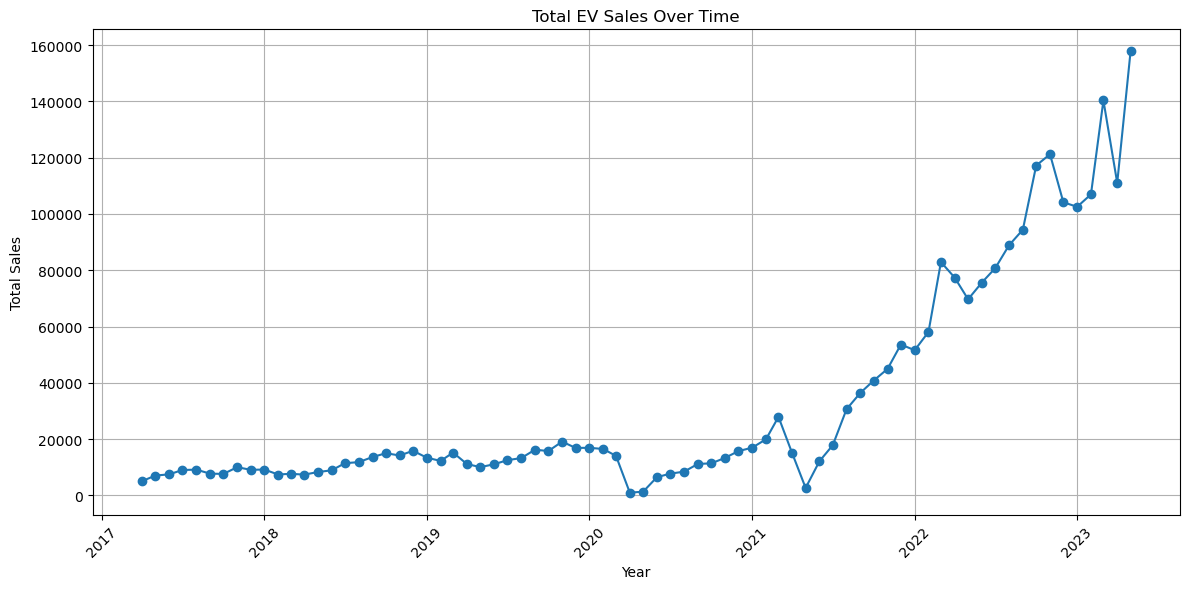

In [42]:
# 13. Line Plot of Total EV Sales Over Time: 
df['YEAR'] = pd.to_datetime(df['YEAR'], format='%b-%y', errors='coerce')

# Sort by date 
df = df.sort_values('YEAR')

plt.figure(figsize=(12, 6))
plt.plot(df['YEAR'], df['Total'], marker='o', linestyle='-')
plt.title('Total EV Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

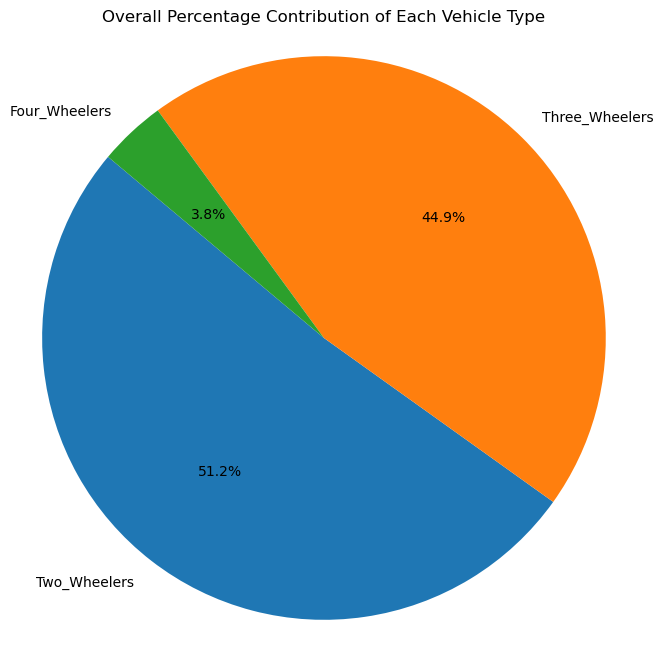

In [43]:
# 14. Pie Chart of Overall Percentage Contribution by Vehicle Type

plt.figure(figsize=(8, 8))
plt.pie(overall_contribution, labels=overall_contribution.index, autopct='%1.1f%%', startangle=140)
plt.title('Overall Percentage Contribution of Each Vehicle Type')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

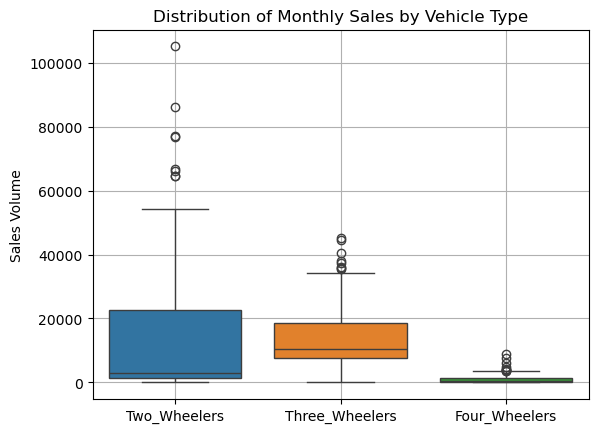

In [44]:
# 15. Boxplot: Distribution of Monthly Sales
sns.boxplot(data = df[['Two_Wheelers', 'Three_Wheelers', 'Four_Wheelers']])
plt.title('Distribution of Monthly Sales by Vehicle Type')
plt.ylabel('Sales Volume')
plt.grid(True)
plt.show()


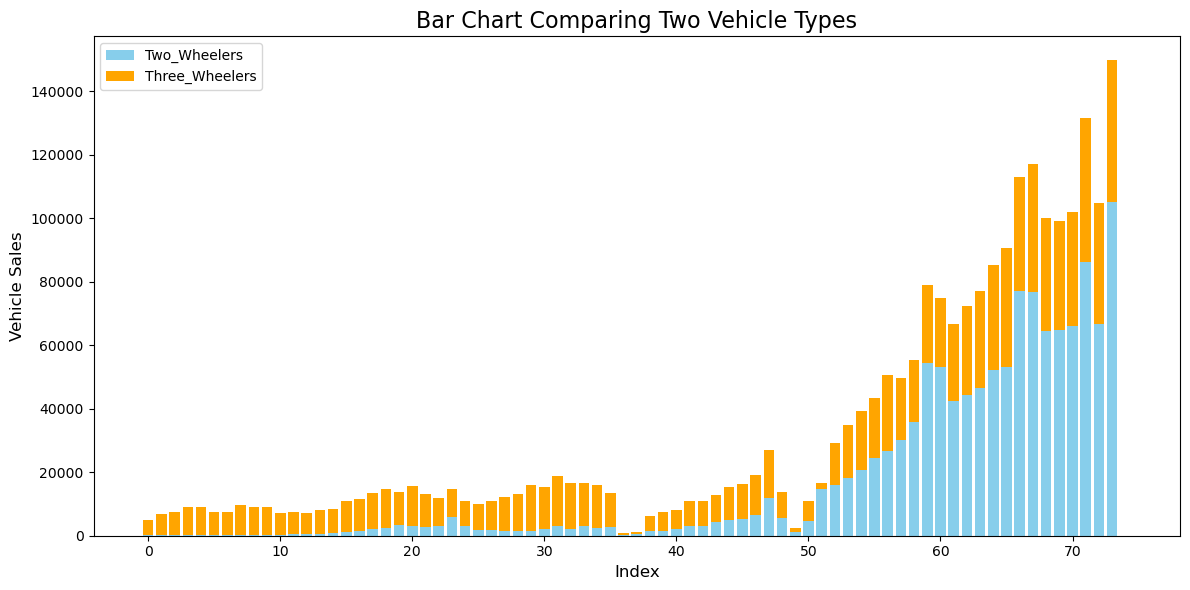

In [47]:
# 16. Scatter Plot for Comparing Two Vehicles

plt.figure(figsize=(12, 6))
plt.bar(df.index, df['Two_Wheelers'], color='skyblue', label='Two_Wheelers')
plt.bar(df.index, df['Three_Wheelers'], bottom=df['Two_Wheelers'], color='orange', label='Three_Wheelers')

plt.title('Bar Chart Comparing Two Vehicle Types', fontsize=16)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Vehicle Sales', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


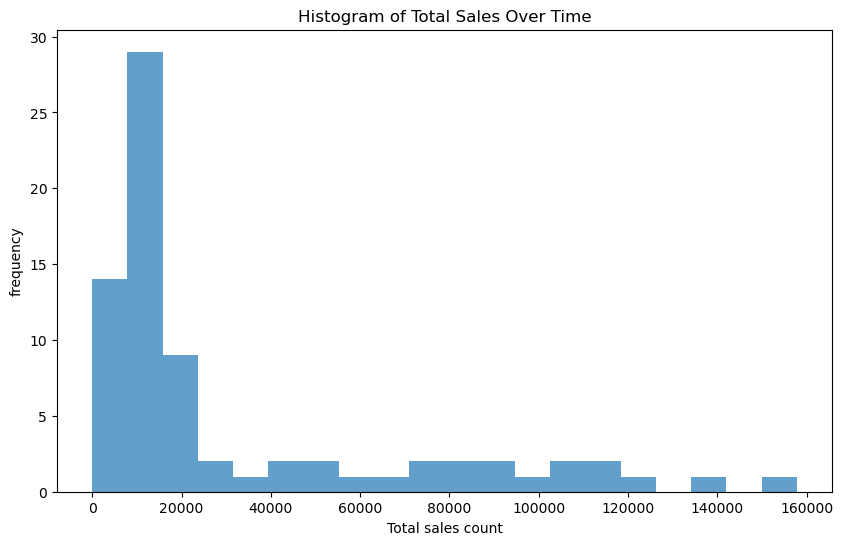

In [48]:
# 17. Total sales over time using Histogram

plt.figure(figsize=(10, 6))
df['Total'].plot(kind='hist', bins=20, alpha=0.7)
plt.title('Histogram of Total Sales Over Time')
plt.xlabel('Total sales count')
plt.ylabel('frequency')
plt.show()

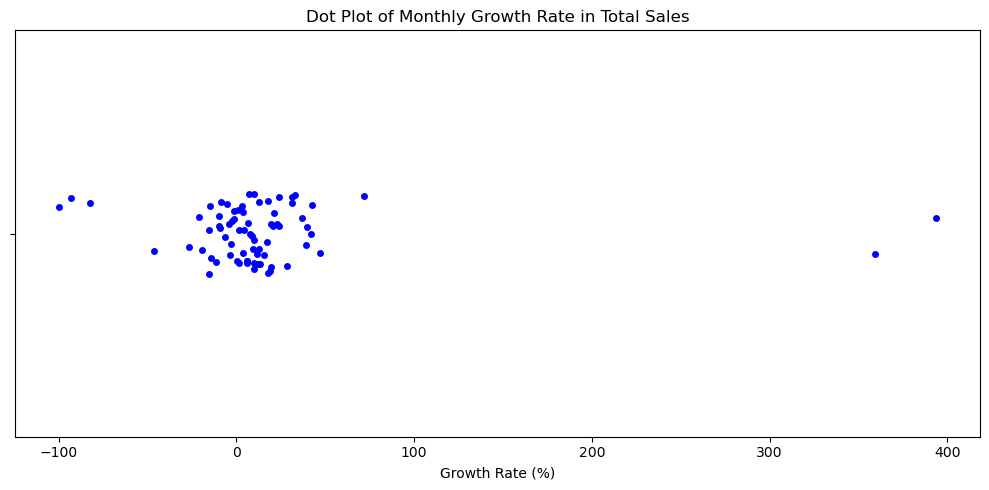

In [52]:
# 18 Calculate monthly growth rate in total sales

growth_data = df['Monthly_Growth_%'].dropna()

# Create dot plot using seaborn
plt.figure(figsize=(10, 5))
sns.stripplot(x=growth_data, color='blue', jitter=True)

plt.title('Dot Plot of Monthly Growth Rate in Total Sales')
plt.xlabel('Growth Rate (%)')
plt.tight_layout()
plt.show()




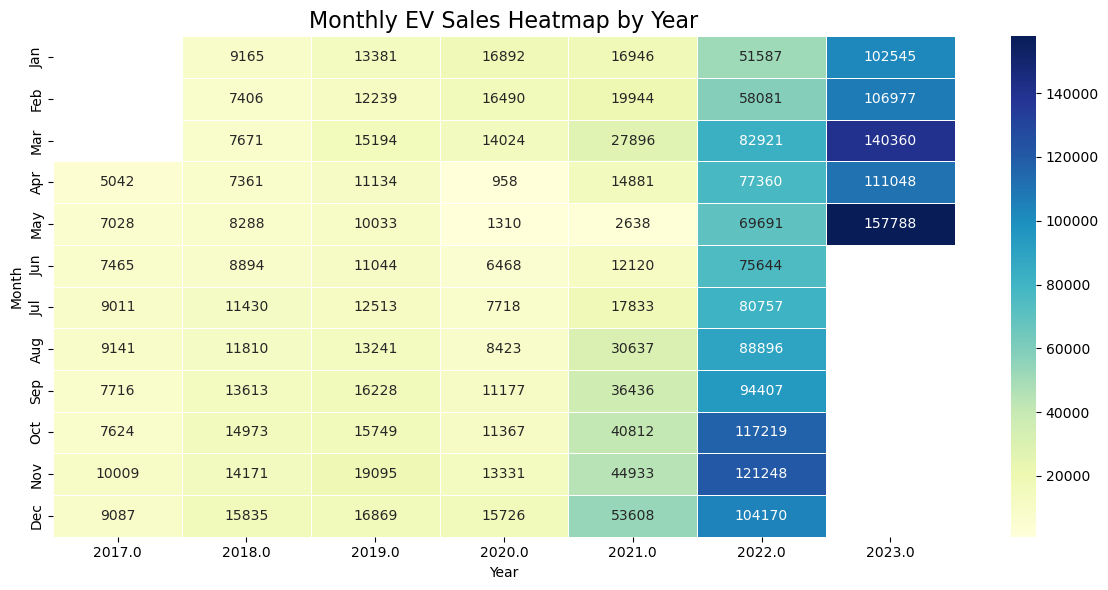

In [56]:
# 19. trend of total EV sales over time using scatter plot

# Ensure 'Date' column is datetime
df['Date'] = pd.to_datetime(df['YEAR'], errors='coerce')

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name().str[:3]  # e.g., Jan, Feb

# Pivot table: index = Month, columns = Year, values = Total Sales
pivot = df.pivot_table(index='Month', columns='Year', values='Total', aggfunc='sum')

# Reorder months properly
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot = pivot.reindex(month_order)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title('Monthly EV Sales Heatmap by Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.show()


